# Импорты, seed и устройство

In [1]:
import os
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights

os.makedirs("artifacts/figures", exist_ok=True)

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

runs_results = []

Используемое устройство: cuda


# Данные и transforms (Часть A - STL10)

In [2]:
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        return self.transform(x), y

    def __len__(self):
        return len(self.subset)


base_trainval_dataset = torchvision.datasets.STL10(root='./data', split='train', download=True)
base_test_dataset = torchvision.datasets.STL10(root='./data', split='test', download=True)


train_len = 4000
val_len = len(base_trainval_dataset) - train_len
train_subset, val_subset = random_split(base_trainval_dataset, [train_len, val_len], generator=torch.Generator().manual_seed(42))


transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(96, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


resnet_weights = ResNet18_Weights.DEFAULT
transform_resnet = resnet_weights.transforms()

print(f"Размер train: {len(train_subset)}, val: {len(val_subset)}, test: {len(base_test_dataset)}")

100.0%


Размер train: 4000, val: 1000, test: 8000


# Sanity-check и визуализация аугментаций

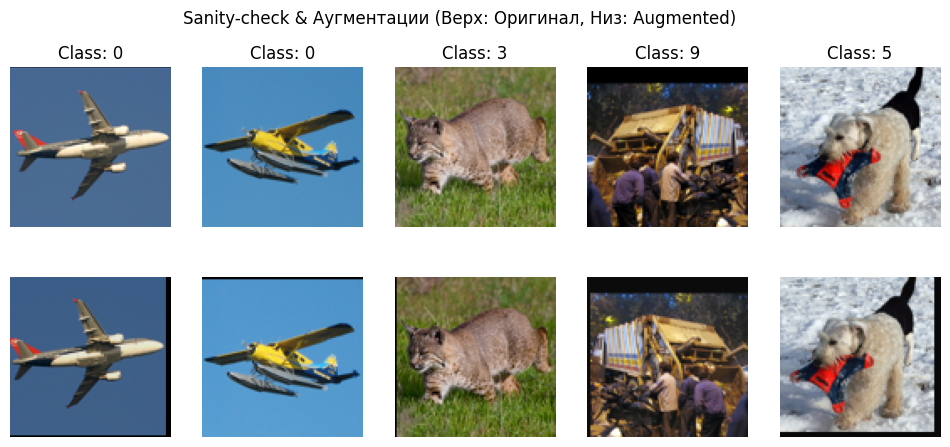

In [3]:
def imshow(img, title=None, save_path=None):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title: plt.title(title)
    plt.axis('off')
    if save_path: plt.savefig(save_path, bbox_inches='tight')
    plt.show()


demo_train_base = TransformSubset(train_subset, transform_base)
demo_train_aug = TransformSubset(train_subset, transform_aug)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sanity-check & Аугментации (Верх: Оригинал, Низ: Augmented)")
for i in range(5):
    img_base, label = demo_train_base[i]
    img_aug, _ = demo_train_aug[i]

    # Base
    ax = axes[0, i]
    ax.imshow(np.transpose((img_base / 2 + 0.5).numpy(), (1, 2, 0)))
    ax.set_title(f"Class: {label}")
    ax.axis('off')

    # Aug
    ax = axes[1, i]
    ax.imshow(np.transpose((img_aug / 2 + 0.5).numpy(), (1, 2, 0)))
    ax.axis('off')

plt.savefig('artifacts/figures/augmentations_preview.png')
plt.show()

# Архитектура SimpleCNN и функции обучения

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 512), nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total

def run_experiment(exp_id, model, train_loader, val_loader, epochs, lr, notes=""):
    print(f"\n--- Запуск {exp_id}: {notes} ---")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = None

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(tr_loss); history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc); history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"Ep {epoch+1}/{epochs} | Tr Loss: {tr_loss:.3f} Acc: {tr_acc:.3f} | Val Loss: {val_loss:.3f} Acc: {val_acc:.3f}")

    runs_results.append({
        'experiment_id': exp_id, 'task': 'classification', 'dataset': 'STL10',
        'seed': 42, 'model_summary': notes, 'optimizer': 'Adam', 'lr': lr,
        'epochs_trained': epochs, 'best_val_accuracy': best_val_acc,
        'test_accuracy': None, 'precision': None, 'recall': None, 'mean_iou': None, 'notes': notes
    })

    return history, best_val_acc, best_weights

# Запуск экспериментов Части A (C1 - C4)

In [5]:
EPOCHS = 5
LR = 1e-3
BATCH_SIZE = 64


train_loader_base = DataLoader(TransformSubset(train_subset, transform_base), batch_size=BATCH_SIZE, shuffle=True)
train_loader_aug = DataLoader(TransformSubset(train_subset, transform_aug), batch_size=BATCH_SIZE, shuffle=True)
val_loader_base = DataLoader(TransformSubset(val_subset, transform_base), batch_size=BATCH_SIZE, shuffle=False)


train_loader_rn = DataLoader(TransformSubset(train_subset, transform_resnet), batch_size=BATCH_SIZE, shuffle=True)
val_loader_rn = DataLoader(TransformSubset(val_subset, transform_resnet), batch_size=BATCH_SIZE, shuffle=False)


hist_c1, val_c1, _ = run_experiment('C1', SimpleCNN(), train_loader_base, val_loader_base, EPOCHS, LR, "simple-cnn-base")


hist_c2, val_c2, _ = run_experiment('C2', SimpleCNN(), train_loader_aug, val_loader_base, EPOCHS, LR, "simple-cnn-aug")


resnet_c3 = resnet18(weights=resnet_weights)
for param in resnet_c3.parameters(): param.requires_grad = False
resnet_c3.fc = nn.Linear(resnet_c3.fc.in_features, 10)
hist_c3, val_c3, _ = run_experiment('C3', resnet_c3, train_loader_rn, val_loader_rn, EPOCHS, LR, "resnet18-head-only")


resnet_c4 = resnet18(weights=resnet_weights)
for param in resnet_c4.parameters(): param.requires_grad = False
for param in resnet_c4.layer4.parameters(): param.requires_grad = True # Разморозка layer4
resnet_c4.fc = nn.Linear(resnet_c4.fc.in_features, 10) # Разморозка fc (по умолчанию requires_grad=True)
hist_c4, val_c4, best_weights_c4 = run_experiment('C4', resnet_c4, train_loader_rn, val_loader_rn, EPOCHS, LR, "resnet18-finetune")

torch.cuda.empty_cache()


--- Запуск C1: simple-cnn-base ---
Ep 1/5 | Tr Loss: 1.783 Acc: 0.329 | Val Loss: 1.577 Acc: 0.407
Ep 2/5 | Tr Loss: 1.379 Acc: 0.485 | Val Loss: 1.411 Acc: 0.473
Ep 3/5 | Tr Loss: 1.130 Acc: 0.585 | Val Loss: 1.287 Acc: 0.547
Ep 4/5 | Tr Loss: 0.855 Acc: 0.691 | Val Loss: 1.255 Acc: 0.560
Ep 5/5 | Tr Loss: 0.602 Acc: 0.787 | Val Loss: 1.422 Acc: 0.548

--- Запуск C2: simple-cnn-aug ---
Ep 1/5 | Tr Loss: 2.005 Acc: 0.239 | Val Loss: 1.628 Acc: 0.378
Ep 2/5 | Tr Loss: 1.600 Acc: 0.398 | Val Loss: 1.490 Acc: 0.430
Ep 3/5 | Tr Loss: 1.410 Acc: 0.476 | Val Loss: 1.514 Acc: 0.395
Ep 4/5 | Tr Loss: 1.276 Acc: 0.521 | Val Loss: 1.245 Acc: 0.535
Ep 5/5 | Tr Loss: 1.140 Acc: 0.584 | Val Loss: 1.224 Acc: 0.541
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Matvej/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%



--- Запуск C3: resnet18-head-only ---
Ep 1/5 | Tr Loss: 1.063 Acc: 0.733 | Val Loss: 0.455 Acc: 0.910
Ep 2/5 | Tr Loss: 0.368 Acc: 0.924 | Val Loss: 0.313 Acc: 0.929
Ep 3/5 | Tr Loss: 0.273 Acc: 0.932 | Val Loss: 0.267 Acc: 0.931
Ep 4/5 | Tr Loss: 0.222 Acc: 0.946 | Val Loss: 0.250 Acc: 0.931
Ep 5/5 | Tr Loss: 0.199 Acc: 0.948 | Val Loss: 0.224 Acc: 0.935

--- Запуск C4: resnet18-finetune ---
Ep 1/5 | Tr Loss: 0.428 Acc: 0.855 | Val Loss: 0.286 Acc: 0.903
Ep 2/5 | Tr Loss: 0.091 Acc: 0.971 | Val Loss: 0.309 Acc: 0.914
Ep 3/5 | Tr Loss: 0.050 Acc: 0.984 | Val Loss: 0.369 Acc: 0.886
Ep 4/5 | Tr Loss: 0.034 Acc: 0.991 | Val Loss: 0.298 Acc: 0.917
Ep 5/5 | Tr Loss: 0.039 Acc: 0.988 | Val Loss: 0.411 Acc: 0.898


# Оценка на Test и сохранение артефактов Части A


--- Финальный тест лучшей модели (C4) ---
Test Accuracy: 0.9187


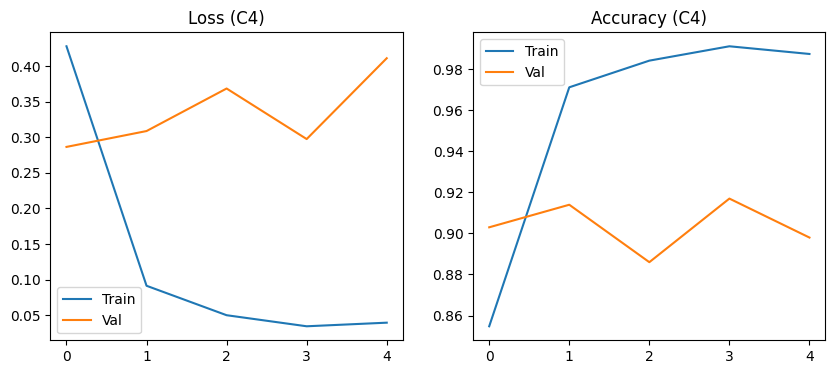

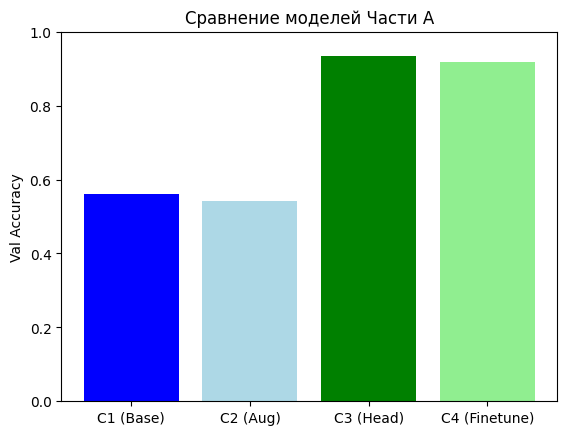

In [6]:
test_loader_rn = DataLoader(TransformSubset(base_test_dataset, transform_resnet), batch_size=BATCH_SIZE, shuffle=False)
best_model = resnet18(weights=None)
best_model.fc = nn.Linear(best_model.fc.in_features, 10)
best_model.load_state_dict(best_weights_c4)
best_model = best_model.to(device)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader_rn, criterion, device)
print(f"\n--- Финальный тест лучшей модели (C4) ---")
print(f"Test Accuracy: {test_acc:.4f}")


for run in runs_results:
    if run['experiment_id'] == 'C4': run['test_accuracy'] = test_acc


torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')
config = {
    "dataset": "STL10", "architecture": "resnet18", "finetune_strategy": "layer4 + fc",
    "transforms": "ResNet18_Weights.DEFAULT.transforms()",
    "batch_size": BATCH_SIZE, "epochs": EPOCHS, "lr": LR, "seed": 42
}
with open('artifacts/best_classifier_config.json', 'w') as f: json.dump(config, f, indent=4)


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_c4['train_loss'], label='Train')
plt.plot(hist_c4['val_loss'], label='Val')
plt.title('Loss (C4)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist_c4['train_acc'], label='Train')
plt.plot(hist_c4['val_acc'], label='Val')
plt.title('Accuracy (C4)')
plt.legend()
plt.savefig('artifacts/figures/classification_curves_best.png')
plt.show()


labels = ['C1 (Base)', 'C2 (Aug)', 'C3 (Head)', 'C4 (Finetune)']
vals = [val_c1, val_c2, val_c3, val_c4]
plt.bar(labels, vals, color=['blue', 'lightblue', 'green', 'lightgreen'])
plt.ylabel('Val Accuracy')
plt.title('Сравнение моделей Части A')
plt.ylim(0, 1.0)
plt.savefig('artifacts/figures/classification_compare.png')
plt.show()

# Часть B - Сегментация (OxfordIIITPet)

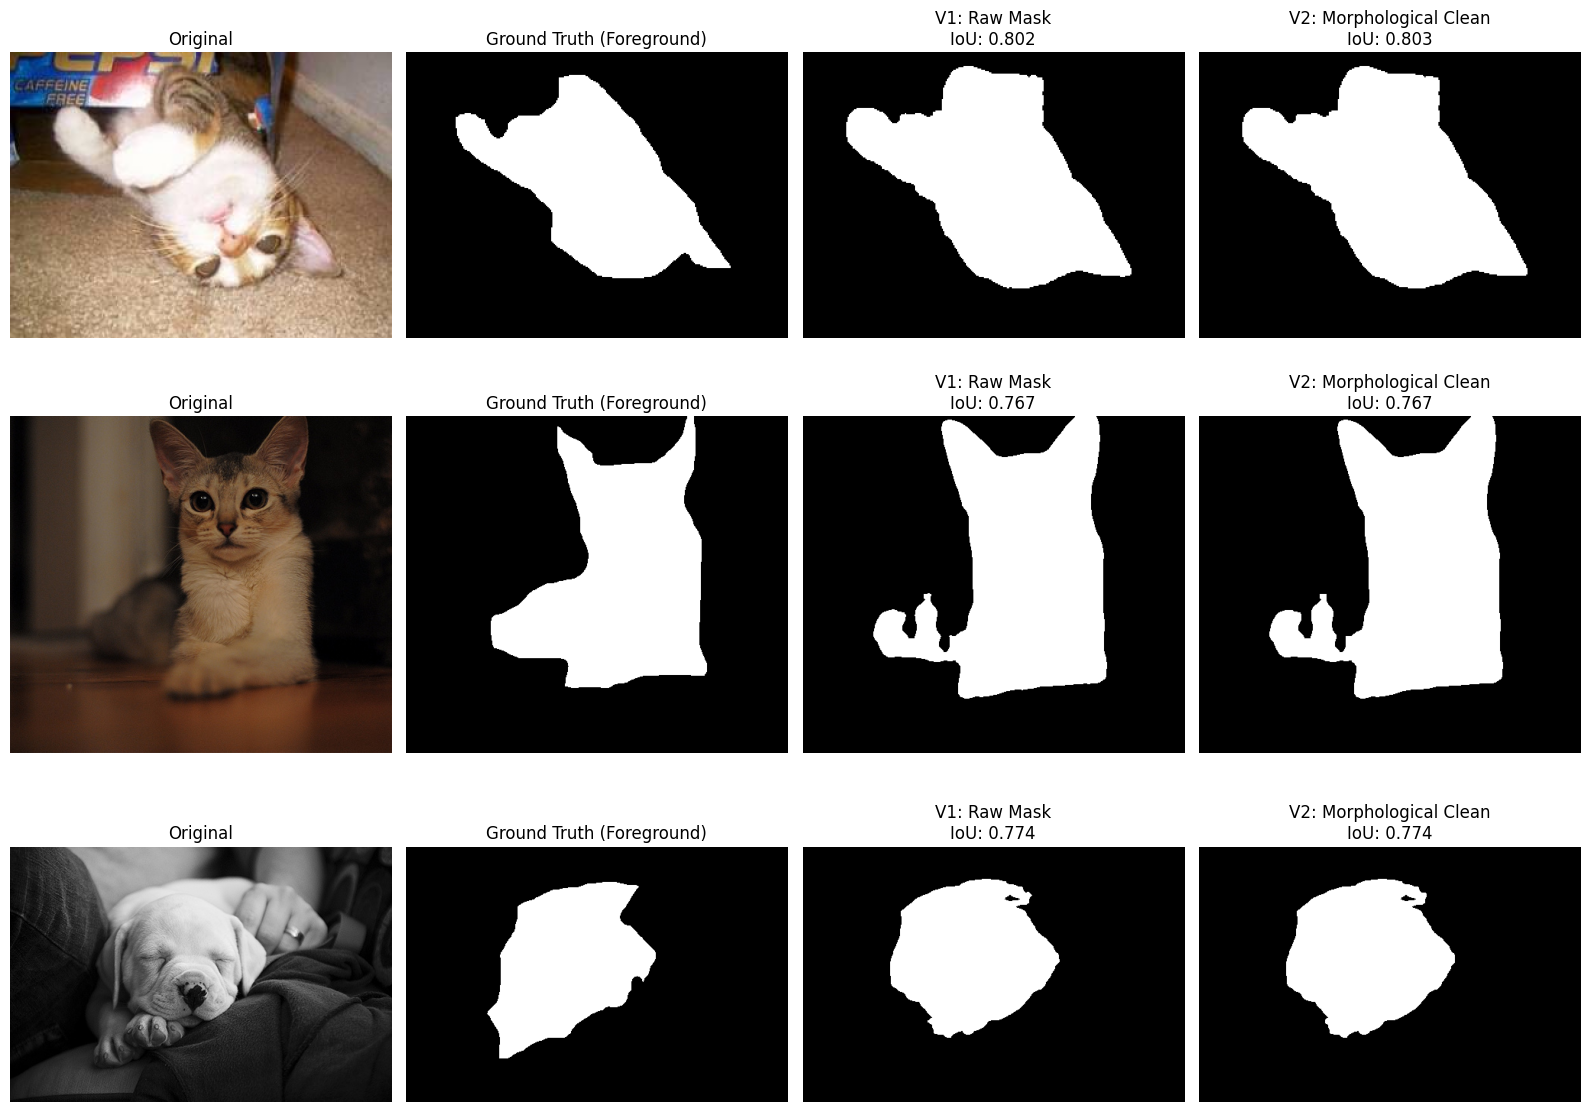

In [8]:
import torch.nn.functional as F


seg_weights = FCN_ResNet50_Weights.DEFAULT
seg_model = fcn_resnet50(weights=seg_weights).to(device)
seg_model.eval()


pet_dataset = torchvision.datasets.OxfordIIITPet(
    root='./data', split='test', target_types='segmentation', download=True,
    transform=transforms.ToTensor(), # Для картинок
    target_transform=transforms.PILToTensor() # Для масок
)


def calculate_iou(pred_mask, true_mask):
    intersection = np.logical_and(pred_mask, true_mask).sum()
    union = np.logical_or(pred_mask, true_mask).sum()
    return intersection / union if union > 0 else 0

iou_v1_list, iou_v2_list = [], []


fig, axes = plt.subplots(3, 4, figsize=(16, 12))
titles = ["Original", "Ground Truth (Foreground)", "V1: Raw Mask", "V2: Morphological Clean"]

for i, ax in zip([10, 50, 100], axes):
    img_tensor, mask_tensor = pet_dataset[i]


    gt_mask = (mask_tensor.squeeze().numpy() == 1)
    orig_h, orig_w = gt_mask.shape


    input_batch = seg_weights.transforms()(img_tensor).unsqueeze(0).to(device)
    with torch.no_grad():
        output = seg_model(input_batch)['out'] # shape: (1, 21, H, W)


    output_resized = F.interpolate(output, size=(orig_h, orig_w), mode='bilinear', align_corners=False)[0]


    pred_classes = output_resized.argmax(0).cpu().numpy()
    pred_foreground = np.isin(pred_classes, [8, 12])


    iou_v1 = calculate_iou(pred_foreground, gt_mask)
    iou_v1_list.append(iou_v1)


    pred_cleaned = ndimage.binary_opening(pred_foreground, structure=np.ones((5,5)))
    iou_v2 = calculate_iou(pred_cleaned, gt_mask)
    iou_v2_list.append(iou_v2)


    ax[0].imshow(img_tensor.permute(1, 2, 0).numpy())
    ax[0].set_title(titles[0]); ax[0].axis('off')

    ax[1].imshow(gt_mask, cmap='gray')
    ax[1].set_title(titles[1]); ax[1].axis('off')

    ax[2].imshow(pred_foreground, cmap='gray')
    ax[2].set_title(f"{titles[2]}\nIoU: {iou_v1:.3f}"); ax[2].axis('off')

    ax[3].imshow(pred_cleaned, cmap='gray')
    ax[3].set_title(f"{titles[3]}\nIoU: {iou_v2:.3f}"); ax[3].axis('off')

plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_examples.png')
plt.show()

# Оценка метрик Части B и сборка runs.csv

In [9]:
import pandas as pd
import numpy as np
from scipy import ndimage
import torch.nn.functional as F


v1_ious, v2_ious = [], []
for i in range(50):
    img_tensor, mask_tensor = pet_dataset[i]


    gt_mask = (mask_tensor.squeeze().numpy() == 1)
    orig_h, orig_w = gt_mask.shape

    input_batch = seg_weights.transforms()(img_tensor).unsqueeze(0).to(device)
    with torch.no_grad():
        output = seg_model(input_batch)['out']


    output_resized = F.interpolate(output, size=(orig_h, orig_w), mode='bilinear', align_corners=False)[0]

    pred_classes = output_resized.argmax(0).cpu().numpy()
    pred_foreground = np.isin(pred_classes, [8, 12])
    pred_cleaned = ndimage.binary_opening(pred_foreground, structure=np.ones((5,5)))

    v1_ious.append(calculate_iou(pred_foreground, gt_mask))
    v2_ious.append(calculate_iou(pred_cleaned, gt_mask))

mean_iou_v1 = np.mean(v1_ious)
mean_iou_v2 = np.mean(v2_ious)
print(f"Mean IoU (V1): {mean_iou_v1:.4f}")
print(f"Mean IoU (V2): {mean_iou_v2:.4f}")


runs_results.append({
    'experiment_id': 'V1', 'task': 'segmentation', 'dataset': 'OxfordIIITPet',
    'seed': 42, 'model_summary': 'fcn_resnet50', 'optimizer': None, 'lr': None,
    'epochs_trained': None, 'best_val_accuracy': None, 'test_accuracy': None,
    'precision': None, 'recall': None, 'mean_iou': mean_iou_v1, 'notes': 'Raw argmax mask'
})


runs_results.append({
    'experiment_id': 'V2', 'task': 'segmentation', 'dataset': 'OxfordIIITPet',
    'seed': 42, 'model_summary': 'fcn_resnet50', 'optimizer': None, 'lr': None,
    'epochs_trained': None, 'best_val_accuracy': None, 'test_accuracy': None,
    'precision': None, 'recall': None, 'mean_iou': mean_iou_v2, 'notes': 'Morphological opening'
})


unique_runs = {run.get('experiment_id'): run for run in runs_results if run.get('experiment_id') is not None}
final_runs = list(unique_runs.values())

# Сохранение runs.csv
df_runs = pd.DataFrame(final_runs)
df_runs.to_csv('artifacts/runs.csv', index=False)
print("\nЭксперименты завершены. runs.csv сохранен.")
df_runs.head(6)

Mean IoU (V1): 0.7609
Mean IoU (V2): 0.7611

Эксперименты завершены. runs.csv сохранен.


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,simple-cnn-base,Adam,0.001,5.0,0.560,NaN,None,None,NaN,simple-cnn-base
1,C2,classification,STL10,42,simple-cnn-aug,Adam,0.001,5.0,0.541,NaN,None,None,NaN,simple-cnn-aug
2,C3,classification,STL10,42,resnet18-head-only,Adam,0.001,5.0,0.935,NaN,None,None,NaN,resnet18-head-only
3,C4,classification,STL10,42,resnet18-finetune,Adam,0.001,5.0,0.917,0.91875,None,None,NaN,resnet18-finetune
4,V1,segmentation,OxfordIIITPet,42,fcn_resnet50,None,NaN,NaN,NaN,NaN,None,None,0.760916,Raw argmax mask
5,V2,segmentation,OxfordIIITPet,42,fcn_resnet50,None,NaN,NaN,NaN,NaN,None,None,0.761110,Morphological opening
